# 07 - Soil Classification Analysis

This notebook analyzes the relationship between earthquake characteristics and soil classification types.

## Soil Classes (TBDY 2018)
- **ZA**: Hard rock (Vs30 > 800 m/s)
- **ZB**: Soft rock (360-800 m/s)
- **ZC**: Dense soil (180-360 m/s)
- **ZD**: Soft soil (< 180 m/s)
- **ZE**: Very soft soil (special soils)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, sys, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
from config import *
from visualization import setup_style
setup_style()

OUTPUT_DIR = os.path.join(FIGURES_PATH, '07_soil')
os.makedirs(OUTPUT_DIR, exist_ok=True)

eq_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'earthquakes_processed.csv'))
eq_df['date'] = pd.to_datetime(eq_df['date'], format='mixed')

print(f"Loaded {len(eq_df):,} records")
print(f"Records with soil data: {eq_df['soil_class'].notna().sum():,}")

Loaded 524,952 records
Records with soil data: 515,089


In [2]:
# Filter records with soil data
eq_soil = eq_df[eq_df['soil_class'].notna()].copy()

print("\nSoil Class Distribution:")
print(eq_soil['soil_class'].value_counts())


Soil Class Distribution:


soil_class
ZC    283216
ZB    186701
ZE     45172
Name: count, dtype: int64


In [3]:
# Statistics by soil class
soil_stats = eq_soil.groupby('soil_class').agg({
    'eventID': 'count',
    'magnitude': ['mean', 'std', 'max'],
    'depth': ['mean', 'std']
}).round(2)
soil_stats.columns = ['count', 'mag_mean', 'mag_std', 'mag_max', 'depth_mean', 'depth_std']
print("\nStatistics by Soil Class:")
soil_stats


Statistics by Soil Class:


,count,mag_mean,mag_std,mag_max,depth_mean,depth_std
soil_class,,,,,,
ZB,186701,1.97,0.73,7.0,7.78,3.37
ZC,283216,1.96,0.69,7.7,8.46,6.53
ZE,45172,2.05,0.69,7.4,7.81,3.92


Soil classes in data: ['ZB', 'ZC', 'ZE']


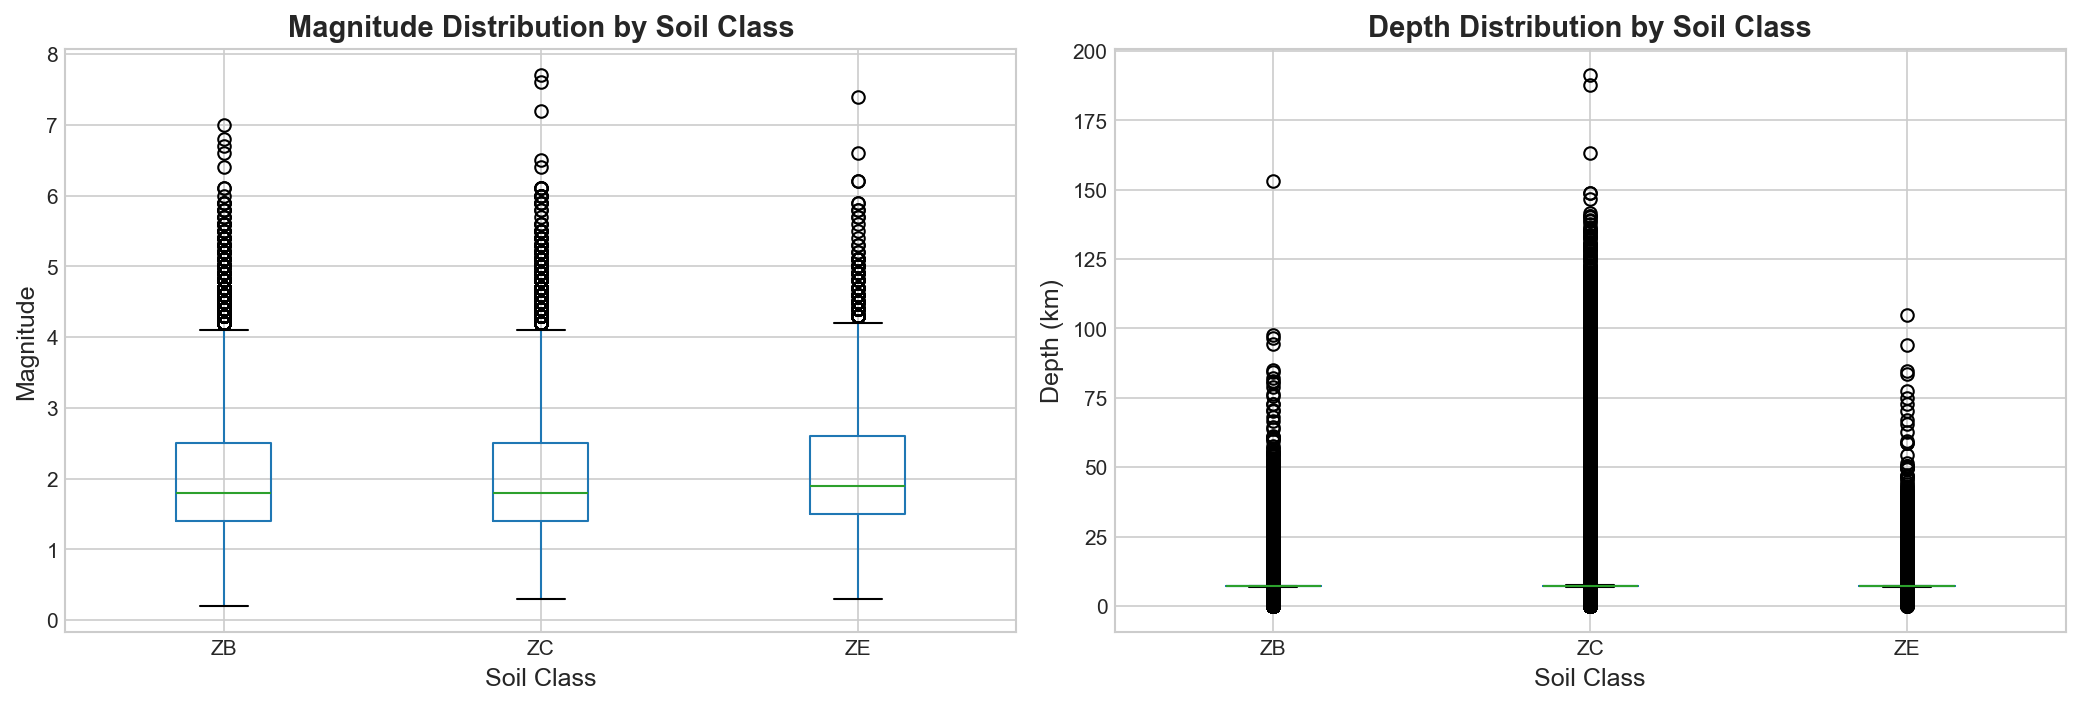

In [4]:
# Box plots by soil class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get actual soil classes present in data
actual_soil_classes = sorted(eq_soil['soil_class'].unique())
print(f"Soil classes in data: {actual_soil_classes}")

# Magnitude by soil class
ax1 = axes[0]
eq_soil.boxplot(column='magnitude', by='soil_class', ax=ax1)
ax1.set_xlabel('Soil Class')
ax1.set_ylabel('Magnitude')
ax1.set_title('Magnitude Distribution by Soil Class', fontweight='bold')
plt.suptitle('')

# Depth by soil class
ax2 = axes[1]
eq_soil.boxplot(column='depth', by='soil_class', ax=ax2)
ax2.set_xlabel('Soil Class')
ax2.set_ylabel('Depth (km)')
ax2.set_title('Depth Distribution by Soil Class', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'soil_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ANOVA test for magnitude differences
actual_classes = sorted(eq_soil['soil_class'].unique())
groups = [eq_soil[eq_soil['soil_class'] == s]['magnitude'].values for s in actual_classes]
f_stat, p_value = stats.f_oneway(*groups)

print("\nANOVA Test (Magnitude by Soil Class):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α=0.05)")


ANOVA Test (Magnitude by Soil Class):
  F-statistic: 280.4048
  p-value: 1.9408e-122
  Result: Significant difference (α=0.05)


In [6]:
# Kruskal-Wallis test (non-parametric)
h_stat, p_value_kw = stats.kruskal(*groups)

print("\nKruskal-Wallis Test (Magnitude by Soil Class):")
print(f"  H-statistic: {h_stat:.4f}")
print(f"  p-value: {p_value_kw:.4e}")


Kruskal-Wallis Test (Magnitude by Soil Class):
  H-statistic: 656.4858
  p-value: 2.7920e-143


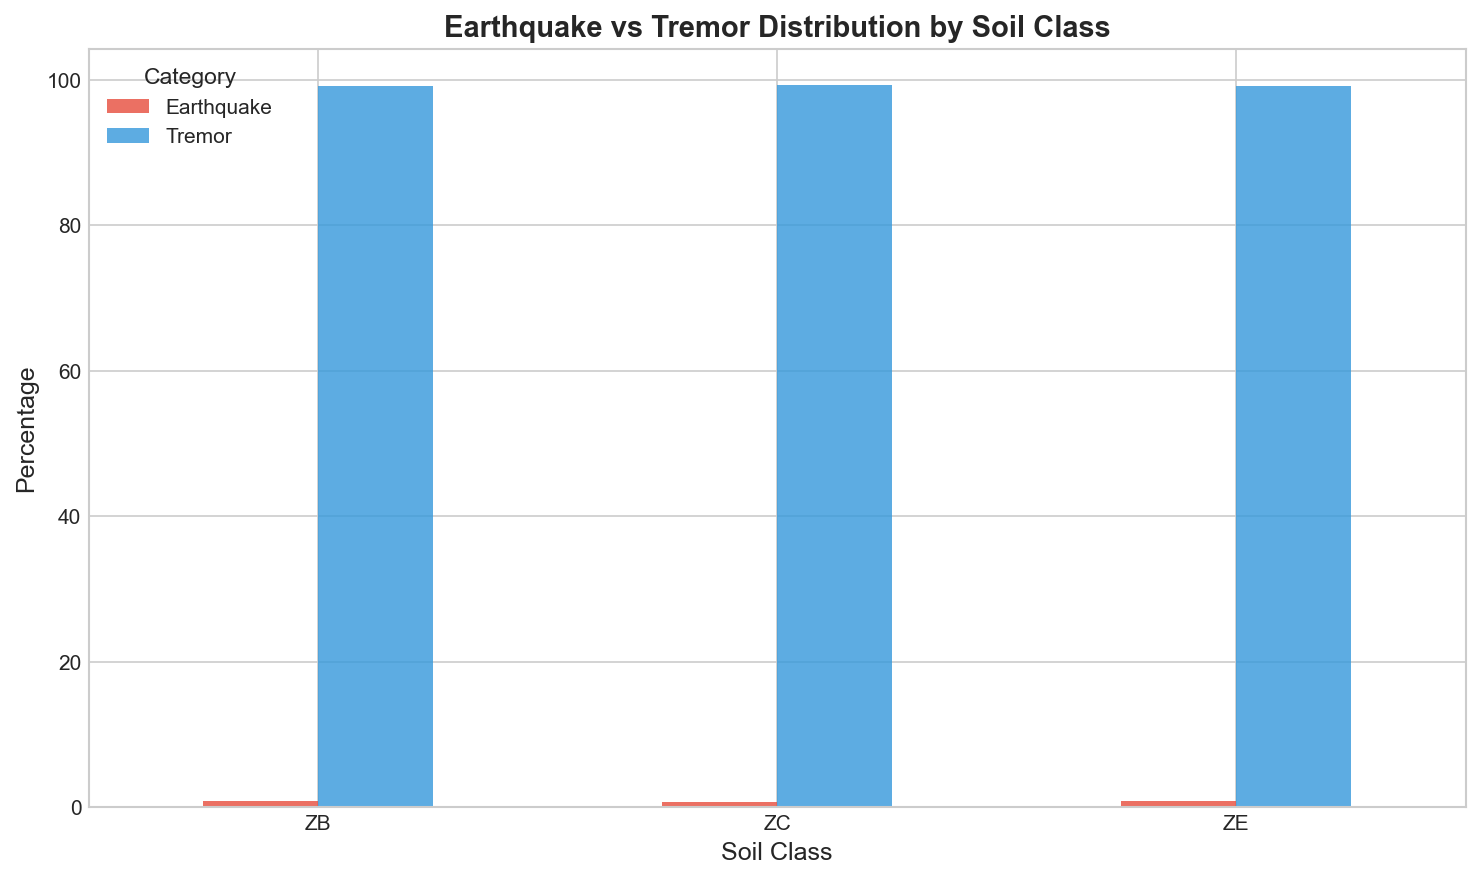

In [7]:
# Earthquake category distribution by soil class
cat_soil = pd.crosstab(eq_soil['soil_class'], eq_soil['category'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
cat_soil.plot(kind='bar', ax=ax, color=[COLORS['earthquake'], COLORS['tremor']], alpha=0.8)
ax.set_xlabel('Soil Class')
ax.set_ylabel('Percentage')
ax.set_title('Earthquake vs Tremor Distribution by Soil Class', fontweight='bold')
ax.legend(title='Category')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'category_by_soil.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Chi-square test for independence
contingency = pd.crosstab(eq_soil['soil_class'], eq_soil['category'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print("\nChi-square Test (Soil Class vs Category Independence):")
print(f"  Chi² = {chi2:.2f}")
print(f"  p-value = {p_val:.4e}")
print(f"  Degrees of freedom = {dof}")
print(f"  Result: {'Dependent' if p_val < 0.05 else 'Independent'} (α=0.05)")


Chi-square Test (Soil Class vs Category Independence):
  Chi² = 21.53
  p-value = 2.1169e-05
  Degrees of freedom = 2
  Result: Dependent (α=0.05)


In [9]:
# Save results
soil_stats.to_csv(os.path.join(TABLES_PATH, 'soil_analysis_results.csv'))
print(f"\nResults saved to: {os.path.join(TABLES_PATH, 'soil_analysis_results.csv')}")
print(f"Figures saved to: {OUTPUT_DIR}")


Results saved to: /Users/boraesen/Desktop/Semester 7/Stat495/stat495project/reports/tables/soil_analysis_results.csv
Figures saved to: /Users/boraesen/Desktop/Semester 7/Stat495/stat495project/reports/figures/07_soil


---
## Geology Type Analysis

Analyzing the distribution of geology types and their relationship with earthquake characteristics and Vs30.


GEOLOGY TYPE ANALYSIS



Records with geology data: 515,089

--- Geology Type Distribution ---
geology_type
Graben sediments         216290
Volcanic/metamorphic     101614
Limestone/alluvium        70490
Volcanic/plateau          39897
Sedimentary basins        37441
Sedimentary/limestone     24830
Metamorphic/volcanic      24527
Name: count, dtype: int64

--- Statistics by Geology Type ---


                        count  mag_mean  mag_std  mag_max  depth_mean  \
geology_type                                                            
Graben sediments       216290      1.96     0.68      6.6        8.19   
Limestone/alluvium      70490      1.99     0.70      7.7        9.07   
Metamorphic/volcanic    24527      1.95     0.74      7.2        7.86   
Sedimentary basins      37441      2.01     0.71      7.4        8.09   
Sedimentary/limestone   24830      1.93     0.70      6.6        7.60   
Volcanic/metamorphic   101614      2.02     0.74      7.0        7.91   
Volcanic/plateau        39897      1.92     0.73      5.9        7.58   

                       depth_std  vs30_mean  vs30_std  
geology_type                                           
Graben sediments            5.57     269.00     59.05  
Limestone/alluvium          8.69     297.50     63.10  
Metamorphic/volcanic        4.04     407.30     48.03  
Sedimentary basins          3.97     191.34     23.08  
Sedime

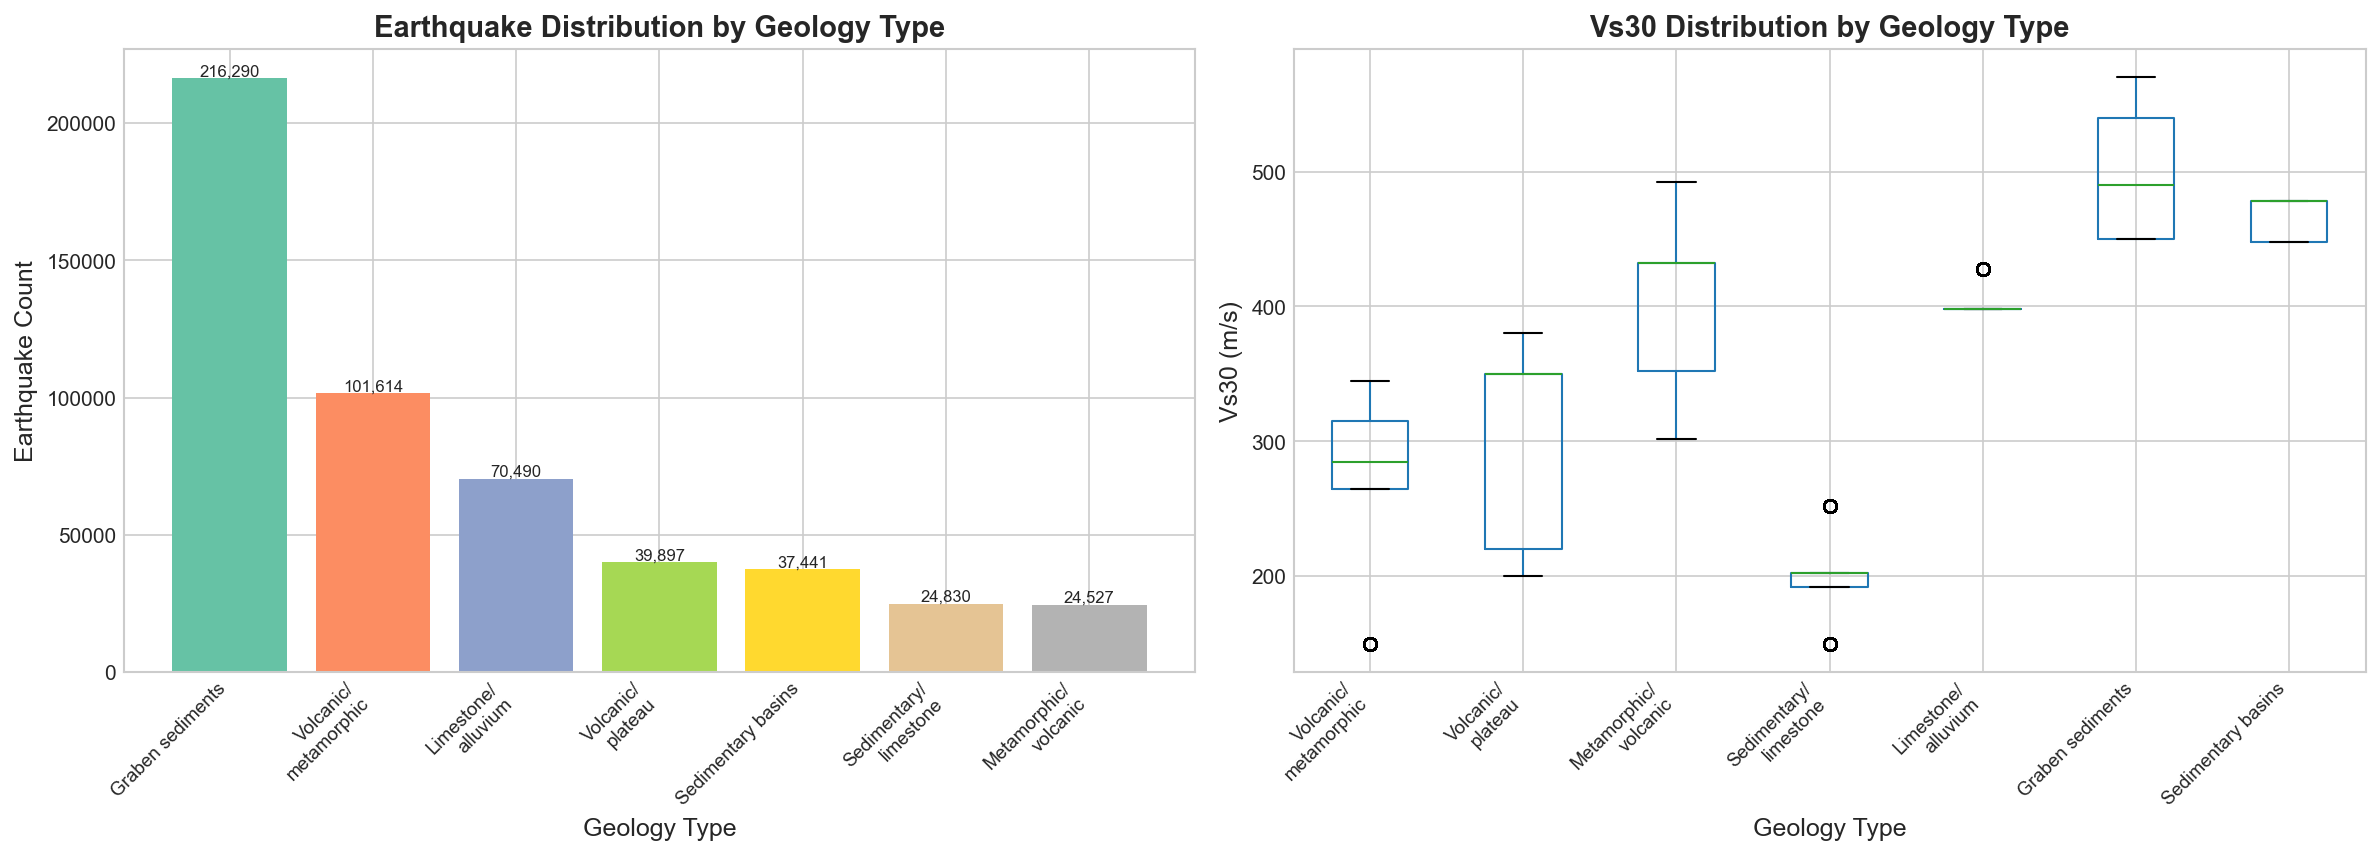

In [10]:
# Geology Type Distribution
print("\n" + "="*70)
print("GEOLOGY TYPE ANALYSIS")
print("="*70)

# Filter records with geology data
eq_geo = eq_df[eq_df['geology_type'].notna()].copy()
print(f"\nRecords with geology data: {len(eq_geo):,}")

# Distribution
print("\n--- Geology Type Distribution ---")
geo_dist = eq_geo['geology_type'].value_counts()
print(geo_dist)

# Statistics by geology type
print("\n--- Statistics by Geology Type ---")
geo_stats = eq_geo.groupby('geology_type').agg({
    'eventID': 'count',
    'magnitude': ['mean', 'std', 'max'],
    'depth': ['mean', 'std'],
    'vs30': ['mean', 'std']
}).round(2)
geo_stats.columns = ['count', 'mag_mean', 'mag_std', 'mag_max', 'depth_mean', 'depth_std', 'vs30_mean', 'vs30_std']
print(geo_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of distribution
ax1 = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(geo_dist)))
bars = ax1.bar(range(len(geo_dist)), geo_dist.values, color=colors)
ax1.set_xticks(range(len(geo_dist)))
ax1.set_xticklabels([g.replace('/', '/\n') for g in geo_dist.index], rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Geology Type')
ax1.set_ylabel('Earthquake Count')
ax1.set_title('Earthquake Distribution by Geology Type', fontweight='bold')
for bar, val in zip(bars, geo_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{val:,}', ha='center', fontsize=8)

# Box plot of Vs30 by geology type
ax2 = axes[1]
geo_order = geo_stats.sort_values('vs30_mean', ascending=False).index.tolist()
eq_geo['geology_order'] = eq_geo['geology_type'].apply(lambda x: geo_order.index(x))
eq_geo_sorted = eq_geo.sort_values('geology_order')
eq_geo_sorted.boxplot(column='vs30', by='geology_type', ax=ax2, positions=range(len(geo_order)))
ax2.set_xticklabels([g.replace('/', '/\n') for g in geo_order], rotation=45, ha='right', fontsize=9)
ax2.set_xlabel('Geology Type')
ax2.set_ylabel('Vs30 (m/s)')
ax2.set_title('Vs30 Distribution by Geology Type', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'geology_type_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Statistical Tests for Geology Type
print("\n--- ANOVA: Vs30 by Geology Type ---")
geo_types = eq_geo['geology_type'].unique()
vs30_groups = [eq_geo[eq_geo['geology_type'] == g]['vs30'].dropna().values for g in geo_types]
f_stat, p_value = stats.f_oneway(*vs30_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α=0.05)")

# Kruskal-Wallis (non-parametric)
print("\n--- Kruskal-Wallis: Vs30 by Geology Type ---")
h_stat, p_kw = stats.kruskal(*vs30_groups)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_kw:.4e}")

# Correlation: Vs30 vs Magnitude (within each geology type)
print("\n--- Correlation: Vs30 vs Magnitude by Geology Type ---")
for g in geo_types:
    subset = eq_geo[eq_geo['geology_type'] == g]
    r, p = stats.pearsonr(subset['vs30'].dropna(), subset.loc[subset['vs30'].notna(), 'magnitude'])
    print(f"{g}: r={r:.4f}, p={p:.4e}")


--- ANOVA: Vs30 by Geology Type ---
F-statistic: 345876.6044
P-value: 0.0000e+00
Result: Significant difference (α=0.05)

--- Kruskal-Wallis: Vs30 by Geology Type ---
H-statistic: 403377.1662
P-value: 0.0000e+00

--- Correlation: Vs30 vs Magnitude by Geology Type ---
Sedimentary basins: r=-0.0547, p=3.5720e-26


Metamorphic/volcanic: r=-0.1109, p=6.1615e-68
Volcanic/plateau: r=-0.1232, p=1.2134e-134
Graben sediments: r=-0.0206, p=1.0715e-21
Sedimentary/limestone: r=0.1344, p=1.8914e-100
Volcanic/metamorphic: r=0.1562, p=0.0000e+00
Limestone/alluvium: r=-0.0692, p=1.1589e-75


---
## Tectonic Setting Analysis

Analyzing the distribution of tectonic settings and their relationship with earthquake characteristics and Vs30.


TECTONIC SETTING ANALYSIS



Records with tectonic data: 515,089

--- Tectonic Setting Distribution ---
tectonic_setting
Active extension    216290
Active collision    101614
Moderate             70490
Low                  39897
Active NAF           37441
Active EAF           24830
Stable               24527
Name: count, dtype: int64

--- Statistics by Tectonic Setting ---


                   count  mag_mean  mag_std  mag_max  depth_mean  depth_std  \
tectonic_setting                                                              
Active EAF         24830      1.93     0.70      6.6        7.60       3.07   
Active NAF         37441      2.01     0.71      7.4        8.09       3.97   
Active collision  101614      2.02     0.74      7.0        7.91       3.32   
Active extension  216290      1.96     0.68      6.6        8.19       5.57   
Low                39897      1.92     0.73      5.9        7.58       3.42   
Moderate           70490      1.99     0.70      7.7        9.07       8.69   
Stable             24527      1.95     0.74      7.2        7.86       4.04   

                  vs30_mean  vs30_std  
tectonic_setting                       
Active EAF           399.56      6.65  
Active NAF           191.34     23.08  
Active collision     496.39     44.82  
Active extension     269.00     59.05  
Low                  463.72     14.98  
Moderate

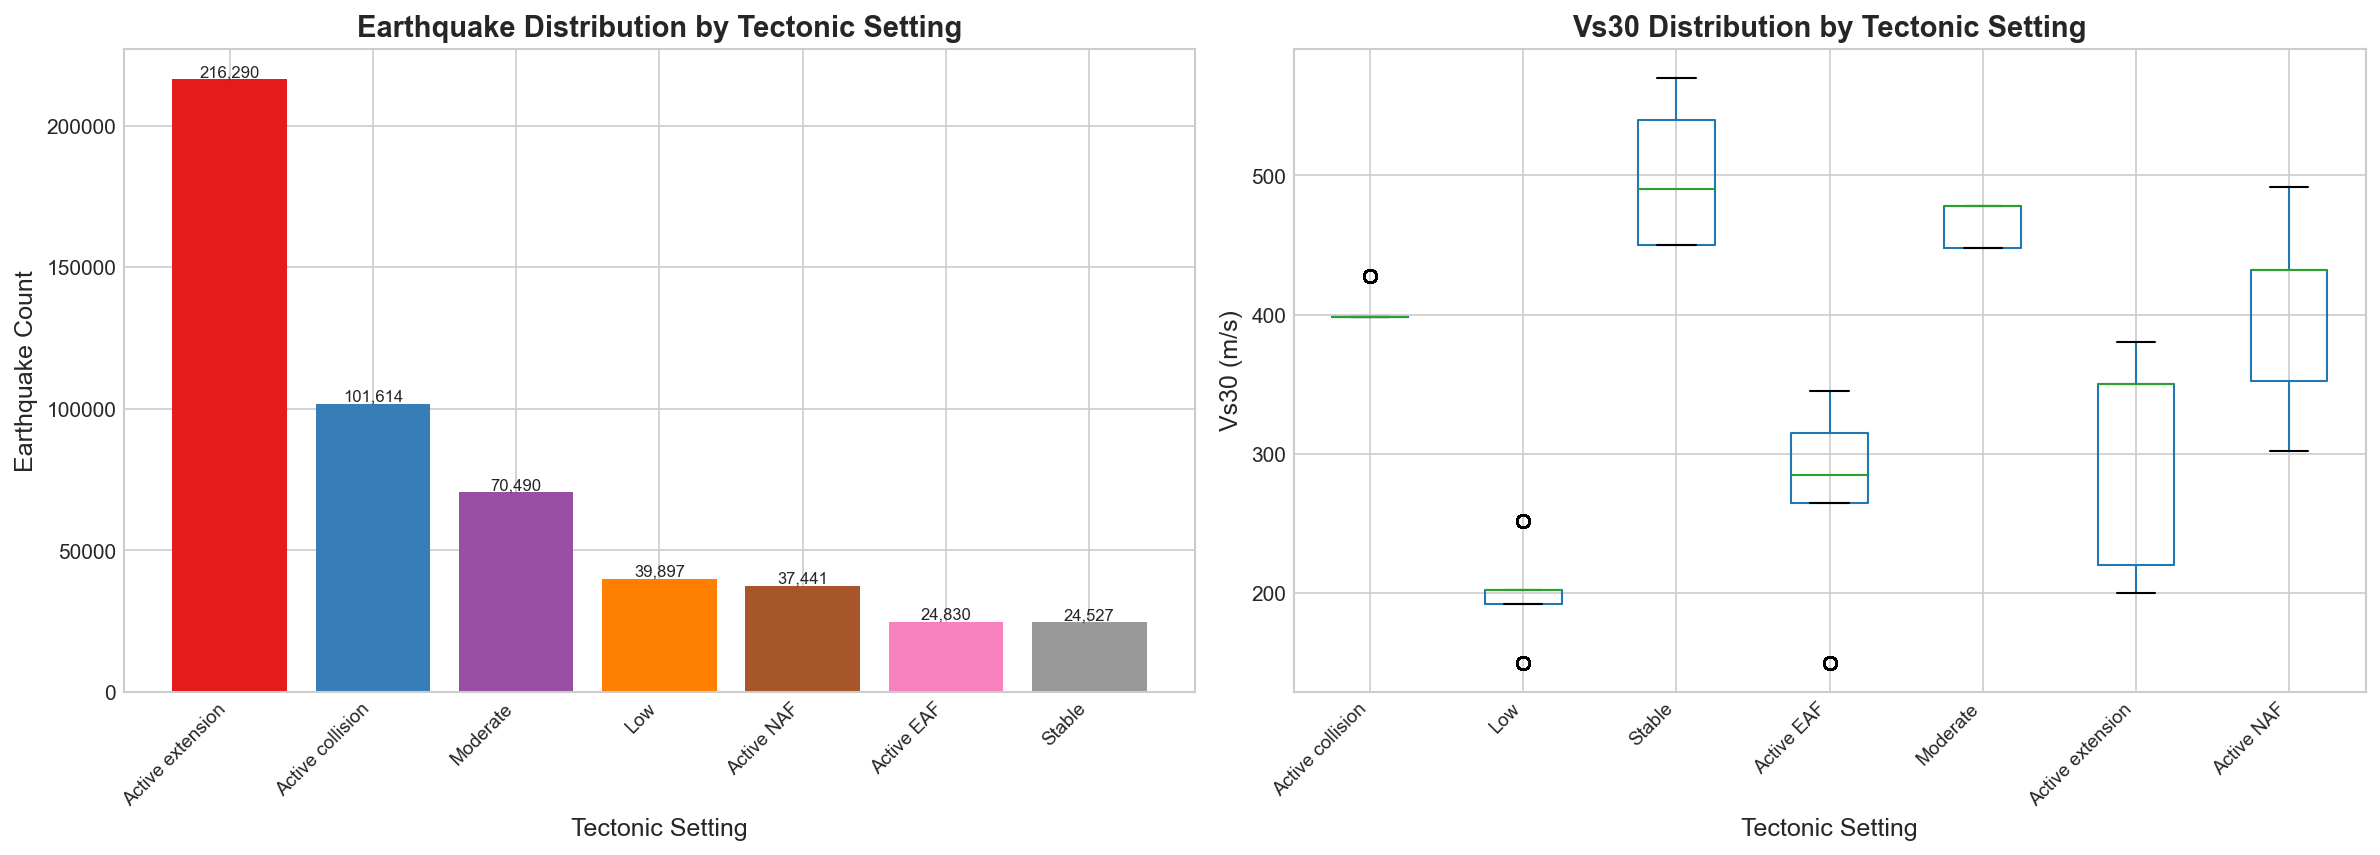

In [12]:
# Tectonic Setting Distribution
print("\n" + "="*70)
print("TECTONIC SETTING ANALYSIS")
print("="*70)

# Filter records with tectonic data
eq_tect = eq_df[eq_df['tectonic_setting'].notna()].copy()
print(f"\nRecords with tectonic data: {len(eq_tect):,}")

# Distribution
print("\n--- Tectonic Setting Distribution ---")
tect_dist = eq_tect['tectonic_setting'].value_counts()
print(tect_dist)

# Statistics by tectonic setting
print("\n--- Statistics by Tectonic Setting ---")
tect_stats = eq_tect.groupby('tectonic_setting').agg({
    'eventID': 'count',
    'magnitude': ['mean', 'std', 'max'],
    'depth': ['mean', 'std'],
    'vs30': ['mean', 'std']
}).round(2)
tect_stats.columns = ['count', 'mag_mean', 'mag_std', 'mag_max', 'depth_mean', 'depth_std', 'vs30_mean', 'vs30_std']
print(tect_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of distribution
ax1 = axes[0]
colors = plt.cm.Set1(np.linspace(0, 1, len(tect_dist)))
bars = ax1.bar(range(len(tect_dist)), tect_dist.values, color=colors)
ax1.set_xticks(range(len(tect_dist)))
ax1.set_xticklabels(tect_dist.index, rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Tectonic Setting')
ax1.set_ylabel('Earthquake Count')
ax1.set_title('Earthquake Distribution by Tectonic Setting', fontweight='bold')
for bar, val in zip(bars, tect_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{val:,}', ha='center', fontsize=8)

# Box plot of Vs30 by tectonic setting
ax2 = axes[1]
tect_order = tect_stats.sort_values('vs30_mean', ascending=False).index.tolist()
eq_tect['tect_order'] = eq_tect['tectonic_setting'].apply(lambda x: tect_order.index(x))
eq_tect_sorted = eq_tect.sort_values('tect_order')
eq_tect_sorted.boxplot(column='vs30', by='tectonic_setting', ax=ax2, positions=range(len(tect_order)))
ax2.set_xticklabels(tect_order, rotation=45, ha='right', fontsize=9)
ax2.set_xlabel('Tectonic Setting')
ax2.set_ylabel('Vs30 (m/s)')
ax2.set_title('Vs30 Distribution by Tectonic Setting', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tectonic_setting_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Statistical Tests for Tectonic Setting
print("\n--- ANOVA: Vs30 by Tectonic Setting ---")
tect_types = eq_tect['tectonic_setting'].unique()
vs30_groups = [eq_tect[eq_tect['tectonic_setting'] == t]['vs30'].dropna().values for t in tect_types]
f_stat, p_value = stats.f_oneway(*vs30_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α=0.05)")

# Kruskal-Wallis (non-parametric)
print("\n--- Kruskal-Wallis: Vs30 by Tectonic Setting ---")
h_stat, p_kw = stats.kruskal(*vs30_groups)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_kw:.4e}")

# Correlation: Vs30 vs Magnitude (within each tectonic setting)
print("\n--- Correlation: Vs30 vs Magnitude by Tectonic Setting ---")
for t in tect_types:
    subset = eq_tect[eq_tect['tectonic_setting'] == t]
    r, p = stats.pearsonr(subset['vs30'].dropna(), subset.loc[subset['vs30'].notna(), 'magnitude'])
    print(f"{t}: r={r:.4f}, p={p:.4e}")


--- ANOVA: Vs30 by Tectonic Setting ---
F-statistic: 345876.6044
P-value: 0.0000e+00
Result: Significant difference (α=0.05)

--- Kruskal-Wallis: Vs30 by Tectonic Setting ---
H-statistic: 403377.1662
P-value: 0.0000e+00

--- Correlation: Vs30 vs Magnitude by Tectonic Setting ---
Active NAF: r=-0.0547, p=3.5720e-26


Stable: r=-0.1109, p=6.1615e-68
Low: r=-0.1232, p=1.2134e-134
Active extension: r=-0.0206, p=1.0715e-21
Active EAF: r=0.1344, p=1.8914e-100
Active collision: r=0.1562, p=0.0000e+00
Moderate: r=-0.0692, p=1.1589e-75



COMBINED ANALYSIS: GEOLOGY TYPE × TECTONIC SETTING


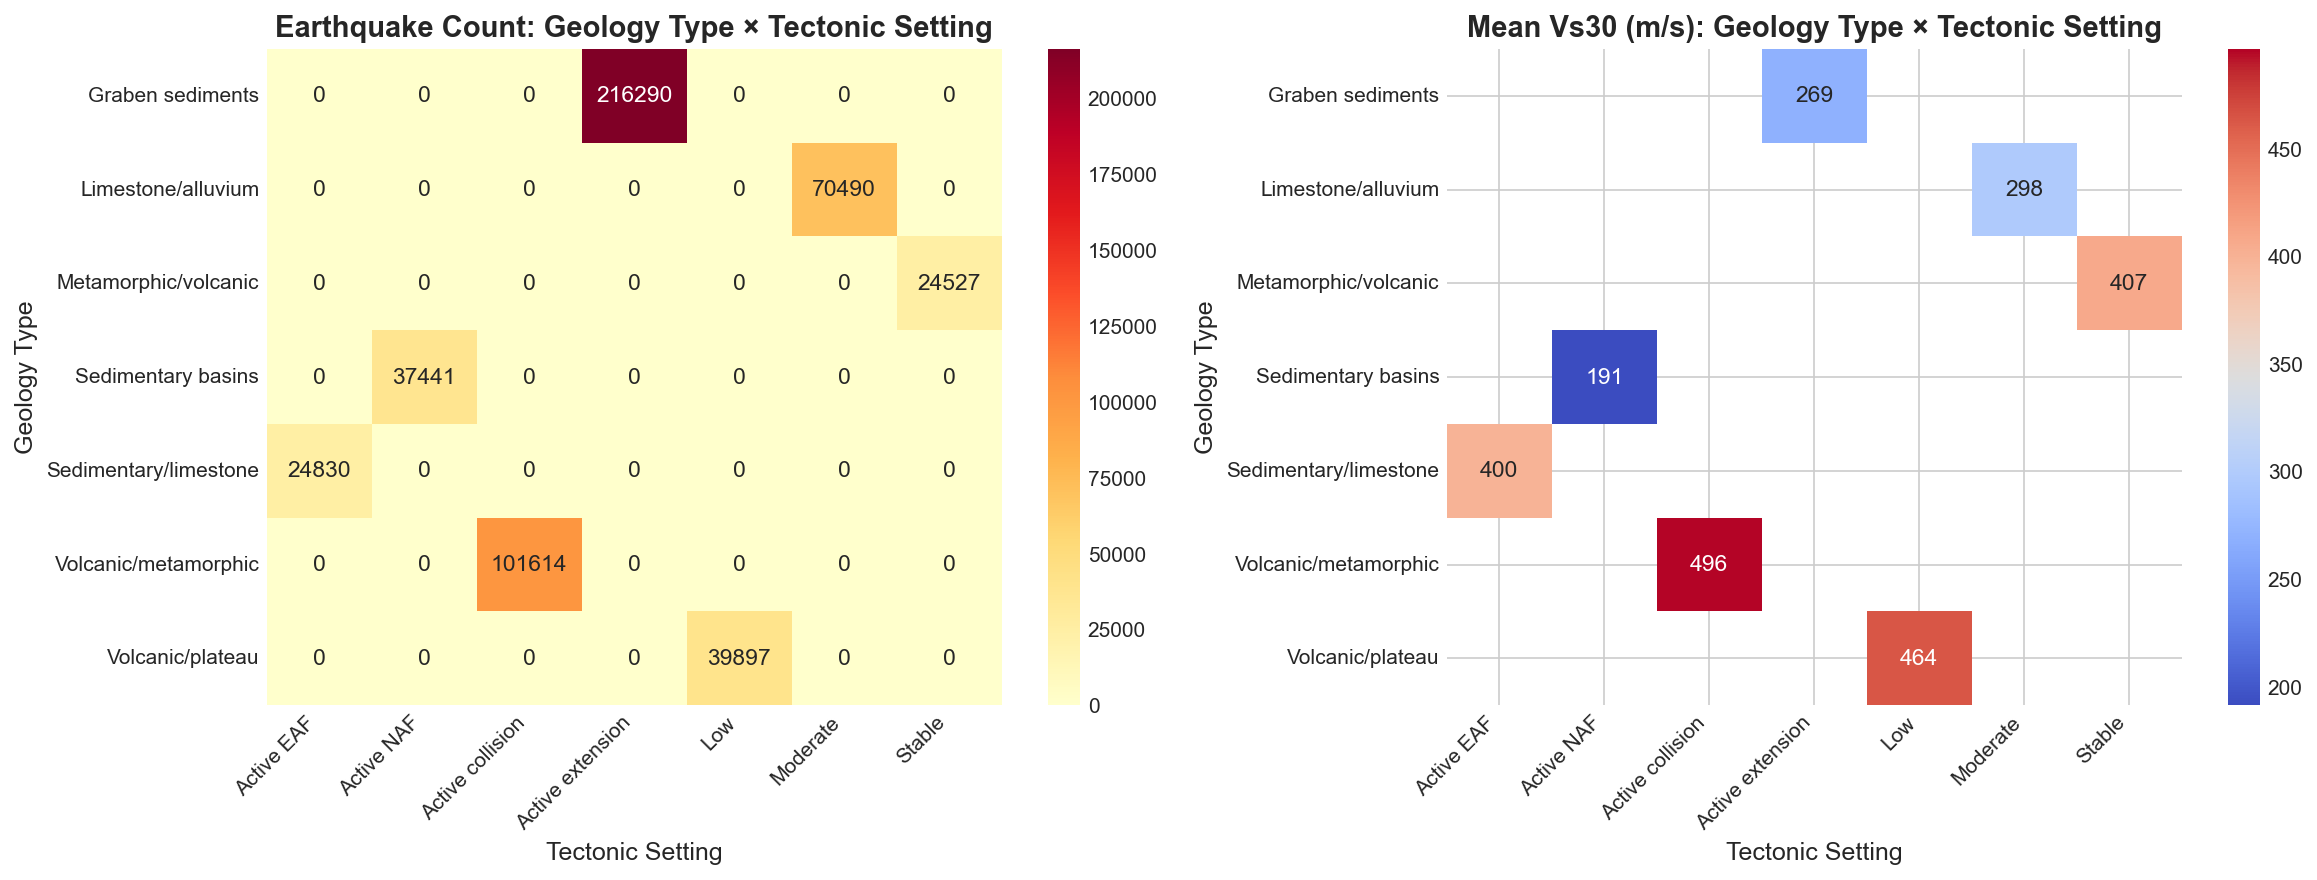


Chi-square Test (Geology Type vs Tectonic Setting):
  Chi² = 3090534.00
  P-value = 0.0000e+00
  Result: Dependent (α=0.05)


In [14]:
# Combined: Geology Type x Tectonic Setting Heatmap
print("\n" + "="*70)
print("COMBINED ANALYSIS: GEOLOGY TYPE × TECTONIC SETTING")
print("="*70)

# Cross-tabulation of geology type and tectonic setting
eq_both = eq_df[(eq_df['geology_type'].notna()) & (eq_df['tectonic_setting'].notna())].copy()
cross_tab = pd.crosstab(eq_both['geology_type'], eq_both['tectonic_setting'])

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count heatmap
ax1 = axes[0]
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=ax1)
ax1.set_title('Earthquake Count: Geology Type × Tectonic Setting', fontweight='bold')
ax1.set_xlabel('Tectonic Setting')
ax1.set_ylabel('Geology Type')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax1.get_yticklabels(), rotation=0)

# Mean Vs30 heatmap
ax2 = axes[1]
vs30_pivot = eq_both.pivot_table(values='vs30', index='geology_type', columns='tectonic_setting', aggfunc='mean')
sns.heatmap(vs30_pivot, annot=True, fmt='.0f', cmap='coolwarm', ax=ax2)
ax2.set_title('Mean Vs30 (m/s): Geology Type × Tectonic Setting', fontweight='bold')
ax2.set_xlabel('Tectonic Setting')
ax2.set_ylabel('Geology Type')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'geology_tectonic_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

# Chi-square test for independence
chi2, p_val, dof, expected = stats.chi2_contingency(cross_tab)
print(f"\nChi-square Test (Geology Type vs Tectonic Setting):")
print(f"  Chi² = {chi2:.2f}")
print(f"  P-value = {p_val:.4e}")
print(f"  Result: {'Dependent' if p_val < 0.05 else 'Independent'} (α=0.05)")

In [15]:
# Save extended results
geo_stats.to_csv(os.path.join(TABLES_PATH, 'geology_type_stats.csv'))
tect_stats.to_csv(os.path.join(TABLES_PATH, 'tectonic_setting_stats.csv'))
print(f"\nGeology type stats saved to: {os.path.join(TABLES_PATH, 'geology_type_stats.csv')}")
print(f"Tectonic setting stats saved to: {os.path.join(TABLES_PATH, 'tectonic_setting_stats.csv')}")


Geology type stats saved to: /Users/boraesen/Desktop/Semester 7/Stat495/stat495project/reports/tables/geology_type_stats.csv
Tectonic setting stats saved to: /Users/boraesen/Desktop/Semester 7/Stat495/stat495project/reports/tables/tectonic_setting_stats.csv
